# **Лекция 1.2. Числовые данные.**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **§1. Представление числовых данных в памяти компьютера**
Компьютеры, которыми мы пользуемся, построены на основе *цифровой логики*.
В этой системе информация представляет из себя простейшие цифровые сигналы `0` и `1`.
Объём информации такой элементарной ячейки называется *битом*.

Любая информация, которую мы хотим хранить или обрабатывать при помощи компьютера, должна быть представлена (*закодирована*) в *двоичном виде*.

Минимальный удобный для хранения в оперативной памяти компьютера квант информации составляет 8 бит. Такое количество информации получило свое название — *байт*.
Если у 1 бита всего 2 состояния, то, исходя из комбинаторики, у байта 256 состояний. Этого мало, чтобы сохранить все возможные числа (тем более, что в математике их бесконечное число), но для начала зададимся хотя бы этим: как назначить коды числам от 0 до 255.

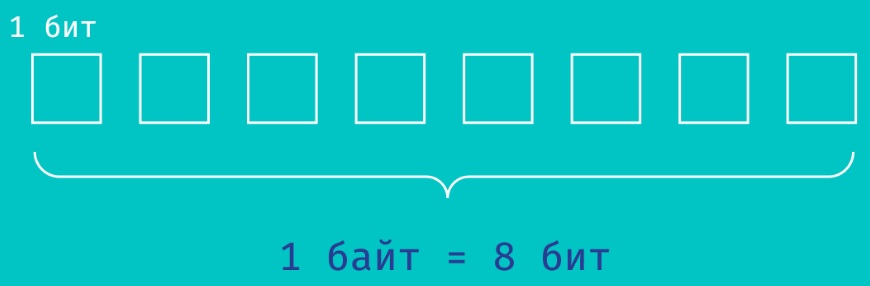

# **§2. Системы счисления**
*Двоичная система счисления.*
Самый простой и естественный путь — воспользоваться двоичной системой счисления с лидирующими *незначащими нулями*:
```
00000000 = 0
00000001 = 1
00000010 = 2
00000011 = 3
00000100 = 4
00000101 = 5
00000110 = 6
00000111 = 7
...      = ...
11111111 = 255
```

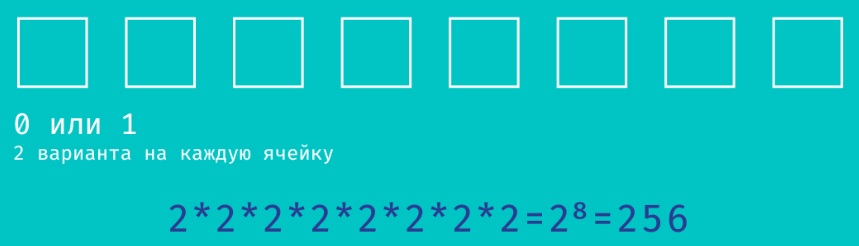

В Python *для целых чисел* реализована **длинная арифметика**, что позволяет создавать очень большие числа. Важно только понимать, что *даже один такой объект числа может занимать очень много оперативной памяти компьютера*. Зато можно не волноваться про переполнения. Этот тип объекта называется `int`.

In [ ]:
2 ** 10

1024

In [ ]:
2 ** 100

1267650600228229401496703205376

In [ ]:
2 ** 1000

10715086071862673209484250490600018105614048117055336074437503883703510511249361224931983788156958581275946729175531468251871452856923140435984577574698574803934567774824230985421074605062371141877954182153046474983581941267398767559165543946077062914571196477686542167660429831652624386837205668069376

In [ ]:
0b11111111 + 5 #перевод из двоичной системы счисления в десятичную

260

In [ ]:
0o76 # перевод из восьмиричной системы счисления в десятичную: 7*8+6

62

In [ ]:
0xF3 # перевод из шестнадцатиричной системы счисления в десятичную: 15(F)*16+3

243

Для того, чтобы создать целое число `int` в Python, нужно просто записать цифрами его литерал, либо запустить *конструктор int*, который умеет делать число из строки:

In [ ]:
x = 123456789
print(x, type(x))

123456789 <class 'int'>


In [ ]:
x = int("12345")
print(x, type(x))

12345 <class 'int'>


# **§3. Дробные числа**

Когда нужно хранить дробные числа, возникает много вопросов. Дело в том, что даже натуральных чисел бесконечно много, а дробных чисел много *континуально*. Их так много, что их нельзя пересчитать даже за бесконечное время. Они бесконечно плотно покрывают окрестность любой точки числовой прямой.

Главных вопроса два:
1. как мы вообще сможем записать значение числа;
2. сможем ли мы это закодировать конечным количеством бит.

Но в любом случае бесконечное многообразие сменится хоть и очень большим, но дискретным набором чисел.

Древние греки знали только рациональные числа — *обыкновенные дроби*. Их можно представить как целый числитель и натуральный знаменатель. В Python для работы с ними есть библиотека **fractions** и класс объектов `Fraction`:

In [ ]:
from fractions import Fraction
a = Fraction(5, 27)
b = Fraction(91, 11)
print(a, '+', b, '=', a + b)
print(a, '-', b, '=', a - b)
print(a, '*', b, '=', a * b)
print(a, '/', b, '=', a / b, "<--- для математической красоты не хватает скобочек")
print('(', a, ')','/', '(', b,')', '=', a / b)

5/27 + 91/11 = 2512/297
5/27 - 91/11 = -2402/297
5/27 * 91/11 = 455/297
5/27 / 91/11 = 55/2457 <--- для математической красоты не хватает скобочек
( 5/27 ) / ( 91/11 ) = 55/2457


Точность хранения числителя и знаменателя теоретически не ограничена, т.к. они имеют длинный тип `int`, но на практике всё опять упирается в память компьютера.

Из школы мы также знаем *десятичные дроби*. Они представлены библиотекой **decimal** и классом объектов `Decimal`:

In [ ]:
from decimal import Decimal
a = Decimal('12.3456786777')
b = Decimal('0.9876')
print(a, '+', b, '=', a + b)
print(a, '-', b, '=', a - b)
print(a, '*', b, '=', a * b)
print(a, '/', b, '=', a / b)

12.3456786777 + 0.9876 = 13.3332786777
12.3456786777 - 0.9876 = 11.3580786777
12.3456786777 * 0.9876 = 12.19259226209652
12.3456786777 / 0.9876 = 12.50068719896719319562575942


Данные объекты активно используются в банковских расчётах, поскольку хорошо воспроизводят вычисления, которые делают люди вручную с десятичными дробями.

Однако для научных вычислений чаще используются *дроби с плавающей точкой* (по-русски — запятой), то есть с мантиссой и экспонентой. По внутреннему хранению они двоичные, но при вводе-выводе для удобства всегда представлены в десятичном виде. Для их использования не нужно подключать библиотек, а представлены они классом объектов `float`.

Числа `float` появляются автоматически, когда целые числа `int` делят друг на друга или возводят в отрицательную степень:

In [ ]:
x = 2 ** -1
print(x, type(x))

0.5 <class 'float'>


In [ ]:
x = 2 / 5
print(x, type(x))

0.4 <class 'float'>


Даже если числа делятся друг на друга нацело, результат будет всё равно `float`:

In [ ]:
x = 10 / 5
print(x, type(x))

2.0 <class 'float'>


Создать такое число можно также из строки при помощи конструктора:

In [ ]:
x = float(input("Введите число с плавающей точкой: "))
print(x, type(x))

Введите число с плавающей точкой: 0.9
0.9 <class 'float'>


# **§4. Обмен переменных значениями**

Классический обмен переменных значениями через доолнительную переменную:

In [ ]:
a = 7
b = 12
print(a, b)
# -------
tmp = a
a = b
b = tmp
# -------
print(a, b)

7 12
12 7


Но в Python это можно сделать так:

In [ ]:
a = 7
b = 12
print(a, b)
# -------
a, b = b, a
# -------
print(a, b)

7 12
12 7


# **§5. Подсчёт ситуаций**
Довольно часто значение переменной меняется по своему собственному старому значению.

Для пары подобных изменений есть свои названия. Увеличение на 1 — это *инкрементация*. Уменьшение на 1 — *декрементация*.

In [ ]:
x = y = 10
print(x, y)
x = x + 1
y = y - 1
print(x, y)

10 10
11 9


Обратите внимание на выражение `x = x + 1`. Здесь икс в выражении справа ссылается на старый объект, который имеет старое значение. Затем вычисляется выражение, и появляется новый объект числа. Затем иксу присваивается (с именем `x` связывается) ссылка на новый объект.

In [ ]:
x += 1  # так красивее, понятнее и удобнее, а смысл тот же — инкрементация
y -= 1  # красивая декрементация
print(x, y, sep="\n")

12
8


Инкрементацию используют для подсчёта ситуаций. Сколько раз встретится такая строка: `x += 1`, тому и будет равно значение "переменной" `x`.

## Cуммирование чисел
Если нужно просуммировать некоторое количество чисел, то нужно создать переменную-аккумулятор, например, `s`, и в начале положить её равной нулю. После этого накапливаем туда сумму оператором `+=`:

In [ ]:
s = 0

x = 4
s += x

x = 6
s += x

x = 15
s += x

print(s)

25


 В цикле это делать удобнее:

In [ ]:
s = 0
for x in 4, 6, 15:
    s += x
print(s)

25


А ещё можно складывать числа, поступающие с клавиатуры:

1.   Новый пункт
2.   Новый пункт



In [ ]:
1+2+3

6

Отлично! Однако указывать сколько раз вводятся числа с клавиатуры через запятую неудобно. Узнаем как для этого использовать `range` в следующем разделе.

# **§6. Цикл while и арифметические расчёты**
Кроме цикла `for` есть цикл `while`. Он выполняет действия в теле цикла до тех пор, пока условие входа в цикл (оно написано в заголовке после слова while) не окажется ложным.

Типичный цикл while:

In [ ]:
x = 0
while x < 100:
    print(x)
    x += 10
print("действие после цикла")

0
10
20
30
40
50
60
70
80
90
действие после цикла


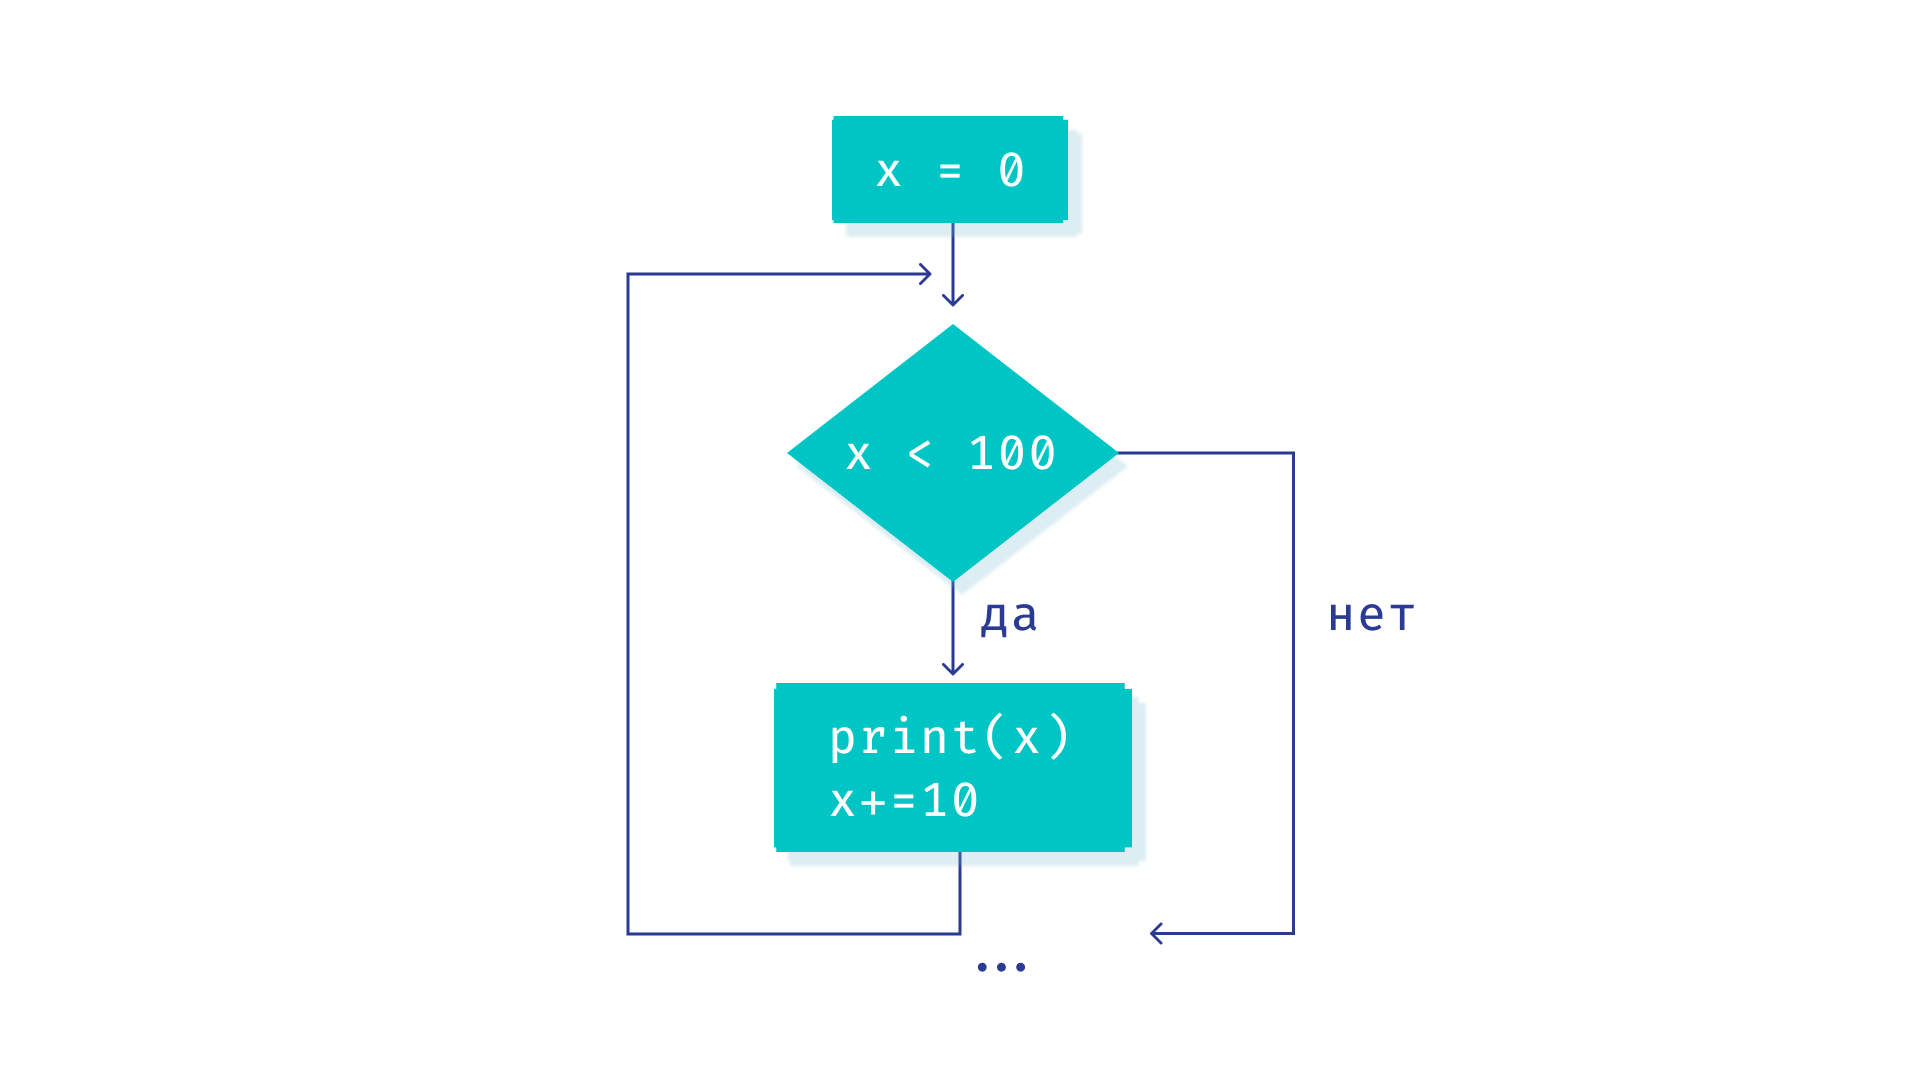

Иногда он может зациклиться навсегда (подумайте, прежде чем запускать):

In [ ]:
x = 1
while x > 0:
    print(x)
    x += 1
print("Никогда...")

Или не выполнить ни одной итерации, если условие сразу оказалось ложным:

In [ ]:
x = 0
while x > 0:
    print(x)
    x += 1

## 6.1 Арифметическая прогрессия
Давайте сделаем арифметическую прогрессию:

In [ ]:
(start, stop, step) = (10, 50, 5)

x = start
while x < stop:
    print(x)
    x += step

10
15
20
25
30
35
40
45


Обратите внимание, что число stop не вошло в прогрессию. Это очень похоже на срезы строк и списков.

Поскольку генерация арифметической прогрессии — типичная задача, в Python есть готовый генератор прогрессий `range(start, stop, step)`, который работает по принципам экономных итерируемых объектов.

In [ ]:
for x in range(10, 50, 5):
    print(x)

10
15
20
25
30
35
40
45


In [ ]:
print(*range(0, 10))

0 1 2 3 4 5 6 7 8 9


In [ ]:
print(*range(9, -1, -1))  # наоборот

9 8 7 6 5 4 3 2 1 0


## 6.2 Геометрическая прогрессия
Зато мы можем теперь сделать геометрическую прогрессию:

In [ ]:
(start, stop, step) = (1, 100, 2)

x = start
while x < stop:
    print(x)
    x *= step

1
2
4
8
16
32
64


Обратите внимание на операцию `x *= step`. Это то же, что `x = x * step`. Так можно поступать и с другими арифметическими операциями.

# **§7. Ветвление хода исполнения программы**
До сих пор наши программы представляли из себя *последовательности действий*, возможно с зацикливаниями.
В таких алгоритмах нет вариативности поведения, не хватает возможности выбора действий, то есть *ветвления*.

Самый простой вариант — это *действие, выполняемое условно*. Оно может произойти, а может и нет:

In [ ]:
x = int(input("Какое сегодня число? "))
if x < 1 or x > 32:
    print('Такого не может быть!')

Какое сегодня число? 65
Такого не может быть!


Второй вариант — это *ветвление с альтернативой*:

In [ ]:
x = int(input("Сколько вам лет? "))
if x < 18:
    print(f'Вам нельзя смотреть этот фильм! Приходите через {18-x} лет.')
    # f-строки делают очень простую вещь — они берут значения переменных,
    # которые есть в текущей области видимости, и подставляют их в строку.
    # В самой строке вам лишь нужно указать имя этой переменной
    # в фигурных скобках
else:
    print('Фильм загружается. Ждите...')

Сколько вам лет? 10
Вам нельзя смотреть этот фильм! Приходите через 8 лет.


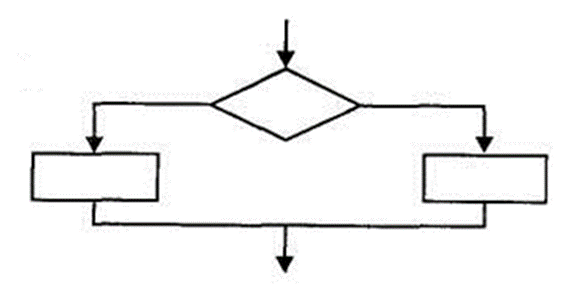

## 7.1 Вложенные условные конструкции
Как и циклы, условные конструкции можно вкладывать друг в друга. Для этого дополнительно увеличивается отступ.
Рассмотрим пример: Определить четверть, в которую попадает заданная точка.
![5678](data:application/octet-stream;base64,iVBORw0KGgoAAAANSUhEUgAAAeIAAAGRCAIAAAA2PSebAAAAAXNSR0IArs4c6QAAKrZJREFUeF7tnd+LVdfZx+P7XodRJ1cRQtDxoiDMtDpjkRGikGTQXkRIGa1QWiykBqG/EMMomEArKL1ovdBRAu2FjT9IwEIcRguZgFpQh0YhZW7USi5ylXE0+QN8v83Du9nZ55x91t6zf6y99mdfDDN71lrPsz7Ps75nnWfvc/aKZ8+ePccBAQhAAAK+EvgfXx3DLwhAAAIQ+C8BZJo8gAAEIOA1AWTa6/DgHAQgAAFkmhyAAAQg4DUBZNrr8OAcBCAAAWSaHIAABCDgNQFk2uvw4BwEIAABZJocgAAEIOA1AWTa6/DgXCeBTz/99O7du8WSuXfv3sTExIoVK1avXq3fo8EvXLigk3a+WIuMBgF3Asi0OytaekHgz3/+889//vNiXfnFL35x/PjxK1euLC0t6fdo8N27d09NTenP1157rViLjAYBdwLItDsrWtZPQFvpy5cvazdd7Ib6zp07w8PDO3bsWLVq1fz8/OLiYjTVgYEB/X7gwIH6J48HbSWATLc18s2ct7bS5njhG2obdmxsTD8XFhYiPP/617/WrVs3Pj7eTGB4HQIBZDqEKLZkDraVtskWvqG2Ybdv366f//znP+3Phw8fXrx48eTJky0hzDT9JIBM+xkXvOpCINpK2//K2FBv2bJFIz969MhM/PGPf3z99ddVDCEeEKiRADJdI3xMZyAQ30pbtzI21N/73vdsE20/T58+feTIkQxe0hQCJRBYwfdNl0CVIYsnsGvXrqjiEY0+MjLy2WefFWtsaGjowYMHWhe6RW/jxo1/+MMfih2f0SCQlQC76azEaF8Dgc6tdHkb6k2bNmnww4cP3759+7e//W0Ns8UkBL5LAJkmIxpAIFGVjntceIX6Bz/4gcY/duzYuXPnBgcHG0AHF0MngEyHHuHmz6/XVrqkDfWGDRs0sj7VwpXD5udOIDOgNh1IIAOeRteqdHy+xVaoR0dHNfjs7Cxb6YCTqllTYzfdrHi1ztv0rXThG+q3335b1w/ff/99NLp1qebxhNlNexwcXHvuuSdPnkR3MYvH97///YhK4h4P7anzATtx4sTTp0/37dunQoc+zHL9+nU+c5iPJL1KIoBMlwSWYUshoC+ri8Yt6l5Sfb+S1NmGPX/+vP4sxXUGhUBeAhQ98pKjXygEVOXQVCYnJ/V5GTQ6lKgGNQ9200GFM/jJlLGbDh4aE2w6AXbTTY8g/kMAAoETQKYDDzDTgwAEmk4AmW56BPEfAhAInAAyHXiAmR4EINB0Ash00yOI/xCAQOAEkOnAA8z0IACBphNAppseQfyHAAQCJ4BMBx5gpgcBCDSdADLd9AjiPwQgEDgBZDrwADM9CECg6QSQ6aZHEP8hAIHACSDTgQeY6UEAAk0ngEw3PYL4DwEIBE4AmQ48wEwPAhBoOgFkuukRxH8IQCBwAsh04AFmehCAQNMJINNNjyD+QwACgRNApgMPMNODAASaTgCZbnoE8R8CEAicADIdeICZHgQg0HQCyHTTI4j/EIBA4ASQ6cADzPQgAIGmE0Cmmx5B/IcABAIngEwHHmCmBwEINJ0AMt30COI/BCAQOAFkOvAAMz0IQKDpBJDppkcQ/yEAgcAJINOBB5jpQQACTSeATDc9gvgPAQgETgCZDjzATA8CEGg6AWS66RHEfwhAIHACyHTgAWZ6EIBA0wkg002PIP5DAAKBE0CmAw8w04MABJpOAJluegTxHwIQCJwAMh14gJkeBCDQdALIdNMjiP9tJLB69eoVK1a0ceatnPOKZ8+etXLiTLqRBOLa1ObUNQ5tJtDI9M3rNLvpvOToBwEIQKASAsh0JZgxAgEIQCAvAY9kurPcRgEub1jp12oC9+7dU1Vk9+7dcQpnzpzRSf2Mn5yZmZmYmNB5HUNDQydOnIj+G523/8YPjb+4uDg6Oho/qT/VXecT6FNMqKW5Kq/U8e2337YlL08uXLjg6EnXyQYWfo9kemlpKQG380xg9JkOBMog8M0332jYJ0+exAd/+vSp/rSfdhw+fHjnzp3379+fmpo6fvz4qlWrDh06JHW2/27cuPH1b49Nmzbpz3Xr1tmfOp5//vmFhYX5+XmdVEcdGkGrVd337t0bN5puQi3N1bm5ufXr158+fXpsbEzmHjx4sGfPnugVJd2TrpMtg2qdY+oqhCeHUYg703nGE1dxoy4C8aVSlw8+2E1fGtevX1cD6WncVYmpTuqnnbQ20sSvvvoqajY5OamT58+fj3e0llHHePe4CY2T8MrFhLUxT6TONrgc0Bm9bMR9i3zu64kPASrWB49203W+WGEbAi0j8MEHH2jG77333uDgYDT1AwcO6PfLly/nhqH9ddTX3YR63blzZ+3atdZX5Rqptrbnt27dcvRE7wlUcrFDZZbO2ovjOH42a7BMU4DzM6XwqnYCL774ony4fft2ilpJFtXm448/jtRNv5iwJqolKdOJxFHFjc2bN0ttP/roo6i9uwkVoxNWVOnWmc8//9wRpnbiKrnYoUqOSijx6rbjIP42K3ZzvpzRjJF70cPlnZ1GU9VMwyqBrABnhbbozZpO9irAKfBmIl6As81C4u1kuonozZreUep9nHU3N3RMT0/blF08SdhdDu2G9o0vpIZOoRC3OxdLYlilSjx1o3yLKgYpkqREdSx6JAbR6ogXTFxMdF3Fsp4o0cQrLelFD9VJrGai4+7du4XQrn2Q78hivd6UIdMu1TH3DFBLCnA+JElfkarXyQqs9yWgRN2/f79tC3RIeU24I40z4dYC6eutY236ypUrZi4SRxcTvWRazse9zbRIo81ZQtD7ztTbBg0ueqS8Vkf/cq+OuYwWtaEAlwkXjasnoIrzqVOnHj9+bNKjCsD27dvjblgOf/3110X5tmPHjnfeeUejXb161cZ0N9FZnLl27ZpG2LJlSz73BgYG8nX0s1eDZZoCXGgFOD+XSKBevfHGG5rZ0aNHExJ548aNhw8f5pv0J598oo4vvfSSdXc3oXv7dCNg5Imq5Co5SuXHx8dzeKJxzp49q44bNmzI0d3HLv7s841O3J/OMxTgjECQBTiXVIwvIZf2obbpuzQ6J95Z7bXCgioVdtlGP23/m6iEpBQ9oss26m59VeiIm+5rIrr8E122id6qqoqSmIWLJ9EsZDqY6De4Nm1qRQEumAKcy6JCpo2SiZoLsaiNLlarS3TJ2s7rapvVrE2vVcJ2FEctveiypHXXn0rFxJ3OfU1EtWlVtO2ubR36pWvRvKtMd3qiGSVu/c4EysPG2SJd6gRy7Kb7bhks8J2Z19nR8TqJOiZ2JS4moiuZCbtZNy/pH1goNTqeDI5MexKIotzodQmxqPHDGKfBtWmXEpJ7dcxlNGtDAc6dFS0hAIHlEwhcpvVxJlVFdIFCV9t0B74uTein7qXfunXrl19+6Ygv/gEn9dWFbL2/i77Xxt2E9s76xMELL7ygqyUaR/fhy4GTJ086uqFmiU8T6DKLZqcr7O4j0BICEGgeAX/eFHSW2yjARdFpQwHOJRUperhQalAblaStGN0gn6t3lae3VPHKqpuctH9XZXl2drYKe+Ha4Okt4caWmfUkEHjRg8hDAAIQaDoBZLrpEcR/CEAgcALIdBUB1teoy8zKlSurMIYNCEAgLALUpsOKZ+izoTYdeoSZXxcC7KZJCwhAAAJeE0CmvQ4PzkEAAhBApskBCEAAAl4TQKa9Dg/OQQACEECmyQEIQAACXhNApr0OD85BAAIQQKbJAQhAAAJeE0CmvQ4PzkEAAhBApskBCECgUgJ6VqG+Uljf5asPK+kYHR2dmZmp1IOmGeNTiE2LWLv95VOITY+/NFrft66vgNfXFI+Njekr1PW16ZqUHrHEN6f3Ci676aanPf5DoB4C9749sto2jdbjLB4/fqzv9ZVM21Pr9IzzrEO1pz0y3Z5YM1MIFElAjzEaGRnR45C0QXYc98KFC9JoffH6qVOnoi779u3T7zrvOEgLmyHTBQedulvBQBmuEgLaF6ugpHpx3JokWCf1s6sLUlsdx44d0xPsHIvLR44c0VD2MzoGBwcrmWKTjVT/wJiALUaPwlLdTRlsDw7X4fJo84CxFDi1+FIrcFiGEgFlbDxXz58/rz/12M90ONPT0/YwPHVXlTmlsT1PS4uis42FlSj0IgCazLmh9O3VRzmtbFPdLWpgdbe+uZ7ZibZ2QKbLi7zpstRWJiJJ1c6jr0Wpsx5maKFRwvdqb2thamoq0SBFvvuabkkDZNo10MpX5bH2Ato7dO0Tz/L4o2bZKbgidmiHTDtAyt/E3v9dv35dSa5DAuo+lt4y2rZag3TtaFLe+c5SZ3Sep9amoG5FbTpH3S0uB1ZuVgFuz549Kt7Nzc11rXJRd2ty8Q/f/0vg4MGD+qnHKy8tLZ07d254eNidi26n09KQUmtzvbCw0NnRLhKuWbMm8a+bN2/qzLZt29xtta6l+6tlo1vmq7tpB613alHpTbuMXhCou1WTHuymS+WsDDfCWfe2WimqZlhfrbWupZJebyttC59p514qBA8Hb0vRI2vdzV2gLajU3apJbmS6PM7aBVutwyC7VKXlTHylSNxTtjJdZdpeGLpeVyxvpo0buS0yrcC4193iF69T0i4ebOpu1aQ+Ml0S5+gmJVWKdQ1cnFMuBpoPcYFWl/TbPNS+q/rb29yUy/IlzbdZw7ZIpiW+0SJPv0POmvVN03ike71xs3eCMt2stPDWW2S6pNCYXFqiWgWv16XyHAJtPtt9UPG1YK8H3AfVN6Ytkmn3ult0d5FE1vGtH3W3vqlWSANkuhCMiUFMLuM3kqZvcqP2fXfQcUN2R4eVODS+VVek0Y5LrIyJN2XMtsh01rqbNN02yPrp8uEU6m7VZDwyXTjn6GMscbm0PY3dQ915qEsmgY5G0FKyPbWtLL1hRaNdAtoKmc5RdzN2dmFQh/bX6flkzRJtqLu5pGCmNsh0Jlw0DoNAK2Q6U90tEVftGqy73qOlbKupu1WzHpDpajhjxSsC4ct01rpb1/BEn7DqFTzqbtWkNTJdDWeseEUgcJnOUXfrFR4VNNKL1NTdKshsZLoCyJjwjQBPb4kvfH73nQBPb/E9QvhXAoFWfKdHCdwYEgIQgEBFBJDpikBjBgIQgEA+Ash0Pm70ggAEIFARAWS6ItCYgQAEIJCPADKdjxu9IAABCFREAJmuCDRmIAABCOQjgEzn40YvCEAAAhURQKYrAo0ZCEAAAvkIINP5uNELAhCAQEUEkOmKQGMGAhCAQD4CyHQ+bvSCAAQgUBEBZLoi0JiBAASMwOLi4okTJ4aGhvQNLTpGR0dnZmaAk0KAr14iPZpEgK9ealK0uvkqjZ6YmJifn9cXuI+Njd2/f19f6a6G+oLJHTt2NH12JfnPbroksAwLgZAJ3Pv2yDFD02h9C/zjx49nZ2cl0/aMpKNHj+YYrSVdkOmWBJppQqBIAlevXh0ZGTl8+LB2x+7jXrhwQRqtxyGdOnUq6rVv3z79rvPu47StJTJdcMSpuxUMlOHKJ6BKsapJZ86ciZvSZlkntfntal9Sq+PYsWPr1693rywfOXJEo9nP6BgcHCx/is22gEwXGT+rux06dEhv6JTEenay9gg7d+50z+MivWEsCLgRGBgYUMMvvvgi3vzSpUv6c/v27V3HGB4eVslienpa/1WGK+0fPnyYbk26rzK0FsX4+LibX7T6fwK+PU7GB3/ufnvk8MQeXKu6W9TX6m46n2M0unQSiC9c+BRF4Pr16wKrjUV8QOmpTkpY062oweTkpMVF2Z7S2NbC1NRUoo3Wms7LXFHTCW+cwJ+FmC9gUT7p+YfuI9hzFxO5rhEsg93HoWUKAWS6jPSwLNWtF9Hg9ghm6a+jueiZzlLbXlscU/POB4pmteXoUkjNwi96UHfjrSME0gmoOix5XVpaiq4Hnjx5Ul0OHDjgiE730s3NzUnotbleWFjo2ssuEq5Zsybx35s3b+rMtm3bHG21sFn4Mk3drYVpzZSzEtCHTdTFFPbGjRu6kUPvCx2LyBJ33fKhGz8k9Or16quvdrVu90erqJ3478WLF3Xmhz/8YVafW9Q+pLcGXedC3S2kEFP0KCmaVujTJUGNL6nV71o4fW2pWqKO2kRbhSS9i8UuMaYtTwrT6ajDr5lSd+u72BrUAJkuKVh2ZUWa61gpjgu0rpn3vdIoty12ies99pIg6yXNK4xhw5dpxcmuWUf54b5ZiGKsqyK2ZeiVT2ai8+KJrmtHm5QwMqbeWSDTJfG32y10S5Iy2UrMvQzlEGgbyu6Dsg27HdJ3M1rSpIIZthUyHdflrjWQlHAqKU1qdWicXvd+dH1DF71C5Lu9L5gkK3AiyHSBMBNDRWzjStppzrTVcQcd7277dCtxaCnZvkcanel+qvKm7/PIrZBp6m4+p2Am35DpTLgyNbbdbt+b8PSG0qXE0dW0lNqsmFhrYaLRLjFqhUxTd3NJhUa0QaZLCpOV9SSd6GZJhJczbCtkmrrbclLEq77IdBnhkDT3urhShjnGzEqgFTItKNTdsmaGn+2R6TLiYhdv0kvSZdhlTEcCbZFp6m6OCeF5M2S68ADZlZv4F9EUboIBl0mgFU9v0Vdz6aOoq1evvnXrFt+aGFe6xv3O01saFzIcXj6B8GVan2TdvHmzrk2rQt35QdXlE2SEKgkg01XSxpYnBML/To+9e/dKo1V3Q6M9yTncgAAEMhEIXKb19Xj6EhnV3d56661MXGgMAQhAwBMC4Rc9PAGNG4UQoOhRCEYGaRaBwHfTzQoG3kIAAhDoJIBMkxUQgAAEvCaATHsdHpyDAAQggEyTAxCAAAS8JoBMex0enIMABCCATJMDEIAABLwmgEx7HR6cgwAEIIBMkwMQgAAEvCaATHsdHpyDAAQggEyTAxCAAAS8JoBMex0enIMABCCATJMDEIAABLwmgEx7HR6cgwAEIIBMkwMQgAAEvCaATHsdHpyDAAQggEyTAxCAAAS8JoBMex0enIMABCCATJMDEIAABLwmgEx7HR6cgwAEIIBMkwMQgAAEvCaATHsdHpyDAAQCIDAzMzM6OqoHLuvn4uKizejevXtDQ0M6qf+mzxGZDiAHmAIEIOAvgYcPH548eXJ2dvb48ePz8/MffvihfNXJbdu2PXjwQL9v3rw53fsVz54983d+eAaB7xLQ1iM6QeqSHc0iIGlet27d66+/LsnWtlrO65fBwcG+s0Cm+yKigUcEkGmPgoEr2QmoyvH48eP9+/dfu3bNUaNlhKJHdtL0gAAEIJCLwGuvvba0tJRJo5HpXKTpBAEIQCAXgZdffln9fvzjH7vUOiIL7KZzwaYTBCAAgYwEdGvH2bNn1enRo0eZuiLTmXDRGAIQgEAeAtJo3drx+9//ftWqVXfu3Mk0BDKdCReNIQABCGQgcOPGjYmJCdPo3d8eY2Njui1Pd324j4JMu7OiJQQgAIFsBP79739fvXp1ZGREt+KdOnVKnXft2qWfuntan3ORgrvoNTKdDTqtIQABCLgTePr0qRrbvdLW680339y0adOhQ4ek0UeOHFm7dm3f0bhvui8iGnhEgPumPQoGrlRFgN10VaSxAwEIQCAXAWQ6FzY6QQACEKiKADJdFWnsQAACEMhFAJnOhY1OEIAABKoigExXRRo7EIAABHIRQKZzYaMTBCAAgaoIINNVkcYOBCAAgVwEkOlc2OgEAQhAoCoCyHRVpLEDAQhAIBcBZDoXNjpBAAIQqIoAMl0VaexAAAIQyEUAmc6FjU4QgAAEqiKATFdFGjsQgAAEchFApnNhoxMEINBiAn/961+rnD0yXSVtbEEAAiEQ+Pvf/67v1P3Nb35TzWSQ6Wo4YwUCEAiNwJ/+9KdqxBqZDi11mA8EIFAlgQrEGpmuMqDYggAEwiRQrlg/++7x2Wef6emKYYJkVhCAAATKJ/DrX/86oavL/PO5RP9XXnml/FlgAQIQgEDgBAoU62TR49GjR4HDY3oQgAAESiawcuXKgYGBJ0+eFGMnsZuem5t7+eWXixmaUSAAAQi0jIAE+ujRo0tLS8ssdMS7r9AfLcPIdBtMQPc/Rd6Tug0OZMNd37Vr1+XLlxOTkED/6le/Uq1DvxQ7P+70KJYno0EAAq0jYDvo//znP++++27hGi2ayHTrUooJQwACRREoW6DNT2S6qHgxDgQg0CIC1Qi0AaU23aLECmCq1KYDCGIAU/j000/1+ZIy6htd4SDTAeRMi6aATLco2Ez1/wlQ9CAXIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE0AmfY6PDgHAQhAAJkmByAAAQh4TQCZ9jo8OAcBCEAAmSYHIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE0AmfY6PDgHAQhAAJkmByAAAQh4TQCZ9jo8OAcBCEAAmSYHIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE0AmfY6PDgHAQhAAJkmByAAAQh4TQCZ9jo8OAcBCEAAmSYHIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE0AmfY6PDgHAQhAAJkmByAAAQh4TQCZ9jo8OAcBCEAAmSYHIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE0AmfY6PDgHAQhAAJkmByAAAQh4TQCZ9jo8OAcBCEAAmSYHIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE0AmfY6PDgHAQhAAJkmByAAAQh4TQCZ9jo8OAcBCEAAmSYHIAABCHhNAJn2Ojw4BwEIQACZJgcgAAEIeE3AX5levXr1ihUr4vBczngNG+cgkJ1APO1PnDihRfH222/3GmZoaEgNHj58mN0OPfwlsOLZs2d+emcaHXfP5Yyfc8GrogjEX7m9Td2iJmvjxNP+3r17IyMjq1atevz4cacV+++6devu379frA+MVi8Bf3fT9XLBOgQ8JDA8PCwVXlpampmZ6XTv0qVLOnnw4EEPPcel5RBAppdDj74QqJrA5OSkTH788cedhi9evKiTr776atU+Ya9kAiHLtN4D6g3j7t274wzPnDmjk/oZP6m9ycTEhM7rUHVPFcDov9F5+2/80PiLi4ujo6Pxk/pT3XU+EbgUE2pprsordVTl0cqR8uTChQuOnnSdbMnJw/A1ENi3b5+sxhPDnFACPHjwYNOmTWvXru10i7VQQ6iKMxmyTH/zzTcC9eTJkziup0+f6k/7acfhw4d37typct7U1NTx48dV+Dt06JDU2f67cePG1789tAD0p95y2p86nn/++YWFhfn5eZ1URx0aQW9I1X3v3r1xo+km1NJcnZubW79+/enTp8fGxmROq27Pnj3RK0q6J10nW1yeMJIvBKTCyg2lWUKpreLxu9/9rqujrAVf4pfPD12H8fOw6cR9czkTb3/9+nV1kZ7GT0pMdVI/7aS1Ud5/9dVXUTN7X3n+/PnO0aKO8e5xExon4aeLCWtjnkidbXA5oDN62Yj7Fvnc1xM/w7pMr+JJvsyhmtK9M+2np6d1Ulkan4LyRCcTqRI1YC00Jdxd/Qx5N+3yuvXBBx+o2XvvvTc4OBi1P3DggH6/fPmyywhd22h/HZ13N6Fed+7cid60qlxj+6Zbt245eqL3BCq52KEyS2ftxXEcmvlM4M0335R7qkRH8VWslScS7ngaZ52Ce6JmGpm1kAlX18Yhy/SLL76oOd++fTtFrSSLaqMLMpG66RfL10S1JIV1JI4qbmzevFl5+dFHH0Xt3U2oGJ2wokq3znz++eeOkdZOXCUXO1TJUQmls4jpOBTNvCUgLbY3fP/4xz/MSbui+NOf/rSXz6yFZq8Fb98LWMItp+ihvipHaJCodmz1ZR1RxSBlKSbeVNrbxq6lhsQgMhcvmLiY6PqeVP4nSjTxSkt60UNvfq1mouPu3bveRjmrY3GYWfs2tH3nQogKYlGKquKhI32CrIXmroWQd9OKyt/+9rf9+/frswC2wbQLgPGlbsItlexMcfd9aLw2feXKFZnTpT9dWzdDyzHx6NGjFJVP+Zc2XKqZ6JKm2ly9ejXfIPTyloDuupMuW93DKh6JO5o6PWctNHctBC7TUqtTp05JN02Fpbzbt2+PZ7AVzr7++uuiFuSOHTveeeedeEK4m+gszly7dk1DbdmyJZ97AwMD+TrSy3MC9jIsJz/88EOrePzkJz9J95m14HlMU9wLXKb7BuaNN95Qm6NHjyYk8saNG7m/GOGTTz7RmC+99JJZdzehe/t0I2DkiarkqjVL5cfHx/tOpLOBxjl79qzOb9iwIUd3unhO4Ec/+pE8fP/997X5yJ0k8Tm6J6o7GdaCOytkuicBbUlUFZE+6gqDLgBKGfVTl/K2bt365ZdfOiKO31+hvioyqNARvQl1N6HFpgueL7zwgsRa46hKIwdOnjzp6IaaJS5mSuU1O23w3UegZVMIKKxKGKWu3eOxfLfdEzXFFmth+YHoMoK311XsPtDOO0PTz/Sdjt1zqp/xlrraFtWsZVdJrxJzYqiulxB1pS66LGlw9acu7nXevppuIrqEqMt90ZLTL12L5o6eaEaJW7/7wvG/QTyD/fe2EA87F0I0rF1h1pHvKjFroZAAVTCIv9+QV8qLkq+Dqsai/buEdXZ21lcfvfCrhd+Q5wX3Cp1gLXTCbnttusL0wxQEIACBPASQ6TzU6AMBCECgMgLIdGWo0wzpW5z075UrV3rhDU5AoD4CrIVO9tSm68tHLGcnQG06OzN6NJ4Au+nGh5AJQAACYRNApsOOL7ODAAQaTwCZbnwImQAEIBA2AWQ67PgyOwhAoPEEkOnGh5AJQAACYRNApsOOL7ODAAQaTwCZbnwImQAEIBA2AWQ67PgyOwhAoPEEkOnGh5AJQAACYRNApsOOL7ODAAQaTwCZbnwImQAEIBA2AWQ67PgyOwhAoPEEkOmKQqgnE+oJXnp0lr48SMfo6KgeCF2RbcxAwCcCrIWs0eAb8rISy9NeeanHG+qxdXpg0tjYmJ4Xp6cUaiA9yosHFWYCyjfkZcLlYWPWQp6gVPAgr5aYSHnwoD0vUU+PTTzFTudbAqeoacZTvKgxGScfAT2AMcczGFkLOWh/55mwOfrTRU+nlUDrGc/aKXelof9KXPScw/h/1csUB4CZCCDTmXCV2tgemDs1NdX5gOZedlkL+SLSapnQXkB5JoWNs1PaWfL1BarsVKbag5+lwr12FhpfDTqfEY5M9yXc2QCZzgHNpUuOtaAuSntFREtA5TsXK6wFF0pd0j5ft2B6WZ5FSWav9n1rEQmB7pTgiE/X7Lf/ItM5sgiZzgHNsUu+tTA9PR3tVHTFJcUWa8ExEMh0kkD8XViURilv4twF2ixFbwwThlNSNncs29ARmS4vylnXQuSJ1HlyctJCo4Tv5SFrIXfsWl30MGrRGzFtCnSkXBWJbxxSdtDxYFj6dr4l1Bmd139zR66dHZHpUuPuvhY63VBK27Zag3RdRKyF3LHjvunnDh48qNzaunXr0tLSuXPnhoeHe90x88tf/lJttCmYnZ0dHx/v1Sx+Xjfh6c81a9YkGt+8eVNntm3b5jIIbSBQDQH3tdDpj24tnZubk1Jrc72wsNDZgLWQP4i5BT6YjtoXG76+e9vonZ371e1eBWjbtuS4nykY7Pkmwm46HzfHXu5rITGgioF27V2Hatxdy4asBccoUJtOEtArv9U6LIf63lqkPDaF1U+Xq9tdU9MWQ+IOk9whbFVHZLq8cGddC+ZJ/GqN9jEpxUDWQu7Ytbo2rQyzm+0luPrsiX5JuQASR2wXQ2wDnq7sXdXfLqmnfBwmdziD74hMlxTiHGshLtBaPum3echt1kLu2LVapk0udWFQ+OzWi14fUenkq6R0uWnUXgbMhB32etD3nr/cEQ27IzJdUnwzrYWsAm0+sxZyx669Mm1yGf8Ad45NbnR1u1cA7I4OK3FofKuuKF/7VldyRzTsjsh0GfHNuhai9n130HFvWQu5Y9dSmY4+xhKXSysZJz7V3ZesRkgvUuu/to8wsVbBBI3uS7VXA2Q6N7peHXOsBXXJJNCRadZCvvDxDXnxhc/vvhPgG/J8jxD+lUCA+6ZLgMqQEIAABIojgEwXx5KRIAABCJRAAJkuASpDQgACECiOADJdHEtGggAEIFACAWS6BKgMCQEIQKA4Ash0cSwZCQIQgEAJBJDpEqAyJAQgAIHiCCDTxbFkJAhAAAIlEECmS4DKkBCAAASKI4BMF8eSkSAAAQiUQACZLgEqQ0IAAhAojgAyXRxLRoIABCBQAgFkugSoDAkBCECgOALIdHEsGQkCEIBACQSQ6RKgMiQEIACB4ggg08WxTB1pcXHxxIkTQ0ND+sZkHaOjozMzMxXZxgwEfCLAWsgaDR4LkJVYnvbKy4mJifn5eT1ka2xs7P79+3r4hQbSwyx27NiRZ8S29uGxAE2PPGshTwTzPfSFXgkC6Y8Jt4dsxZ+7aM8m58G1WRMpnuJZ+9K+GgKshcI5t/RZiEVx1FMNlZR6wmHKI8ntWXOJRyyqoylOUZ60ZBxk2ttAsxbKC017ZcL2s9PT03G4d+/e7ZTUrvSVlBrBnhQuCVbHXkGSiKuNnoebaIBM50hrZDoHtL5dWAt9EdXboL2XEAcGBrTmv/jii/jKv3Tpkv7cvn17Sv3ILoCsX7/+0KFDKjRLf2dnZ4eHh7t2uXfvnsrQUurx8fE8NSn6QKB8AqyF8hkvz0K9rxI1Wpe8dm6cbefb6+H2iR105wa5czq2T5mamkr8y7btMlcjgSaaZjddRtRYC2VQLXDM9hY9rDocrynrvgudmZyc7MpX5ZGoxOEi0DaIRtOYGjkxZrqtAgMc2FDIdBkBZS2UQbXAMdsr04Joe2flqAFViblrEdn+awKh3XEm+mais3Kt/bXOJyrjmUZuZ2NkuqS4sxZKAlvIsK2W6bgud33fF0ds+2KrYETK3jcG1qWzWS/57jtgyxsg0yUlAGuhJLCFDNtqmY5f4E7fShtrSbnJq3521jG6xqOrTNtLAoXpHBmMTOeA5tKFteBCqa42rZZpu6NZCZqpUmwJbVXsvttqa5loZi8J6Z8CqCshPLeLTJcUINZCSWALGbbVMm23W+ijgPb5lF43eHSCVkuTWvVK31bb5w/jNWh9FtGMFhK/tg2CTJcUcdZCSWALGbbVMi2C0bLPcTVPAm33fqREwvbpVuKQslt7aXTfbXgh0Q1vEGS6vJiyFspju8yR2y7TttvtdRNeX7hS275FajUwKybWqpmg0X3B9mqATOdG17cja6EvoroatPob8vQRwW3btq1evfrWrVuDg4NxCeB3PwnwDXklxYW1UBLYQoZtr0zrM9+bN29WlVlVuV4f9S4EMYMUSACZLhBmNBRroQyqBY7Z3u/02Lt3rzRaJWk0usB8YqgmEmAteB61lsq0vjvp6tWruunirbfe8jxCuAeBUgmwFkrFW8jg7S16FIKPQSomQNGjYuCY84FAS3fTPqDHBwhAAAIuBJBpF0q0gQAEIFAbAWS6NvQYhgAEIOBCAJl2oUQbCEAAArURQKZrQ49hCEAAAi4EkGkXSrSBAAQgUBsBZLo29BiGAAQg4EIAmXahRBsIQAACtRFApmtDj2EIQAACLgSQaRdKtIEABCBQGwFkujb0GIYABCDgQgCZdqFEGwhAAAK1EUCma0OPYQhAAAIuBJBpF0q0gQAEIFAbAWS6NvQYhgAEIOBCAJl2oUQbCEAAArURQKZrQ49hCEAAAi4EkGkXSrSBAAQgUBsBZLo29BiGAAQg4EIAmXahRBsIQAACtRFApmtDj2EIQAACLgSQaRdKtIEABCBQGwFkujb0GIYABCDgQgCZdqFEGwhAAAK1EUCma0OPYQhAAAIuBJBpF0q0gQAEIFAbAWS6NvQYhgAEIOBCAJl2oUQbCEAAArURQKZrQ49hCEAAAi4EkGkXSrSBAAQgUBsBZLo29BiGAAQg4EIAmXahRBsIQAACtRFApmtDj2EIQAACLgSQaRdKtIEABCBQGwFkujb0GIYABCDgQgCZdqFEGwhAAAK1EUCma0OPYQhAAAIuBJBpF0q0gQAEIFAbAWS6NvQYhgAEIOBCAJl2oUQbCEAAArURQKZrQ49hCEAAAi4EkGkXSrSBAAQgUBsBZLo29BiGAAQg4EIAmXahRBsIQAACtRFApmtDj2EIQAACLgSQaRdKtIEABCBQGwFkujb0GIYABCDgQgCZdqFEGwhAAAK1EUCma0OPYQhAAAIuBJBpF0q0gQAEIFAbAWS6NvQYhgAEIOBCAJl2oUQbCEAAArURQKZrQ49hCEAAAi4EkGkXSrSBAAQgUBsBZLo29BiGAAQg4EIAmXahRBsIQAACtRFApmtDj2EIQAACLgSQaRdKtIEABCBQGwFkujb0GIYABCDgQgCZdqFEGwhAAAK1EUCma0OP4RwEfvazn1mvV155JUd3ukCgiQT+9913322i3/jcTgIjIyNPnz5duXLlX/7yF/1sJwRm3TYCK549e9a2OTNfCEAAAg0iQNGjQcHCVQhAoI0EkOk2Rp05QwACDSKATDcoWLgKAQi0kQAy3caoM2cIQKBBBJDpBgULVyEAgTYSQKbbGHXmDAEINIgAMt2gYOEqBCDQRgL/B9869LsU9tDnAAAAAElFTkSuQmCC)

In [ ]:
x, y = input("Введите координаты точки — два числа через пробел: ").split()
x, y = int(x), int(y)
if y > 0:
    if x > 0:
        print('Точка в I четверти.')
    else:
        print('Точка во II четверти.')
else:
    if x < 0:
        print('Точка в III четверти.')
    else:
        print('Точка в IV четверти.')

Введите координаты точки — два числа через пробел: 4 -7
Точка в IV четверти.


Замечательно! Из четырёх `print` будет всегда выбираться и срабатывать только один.

Но кое-что всё-таки не так с этой конструкцией. Мы предполагаем, что точка вообще находится в какой-то четверти, а она может быть и на осях. Поэкспериментируйте с точками (0, 0), (0, 10), (0, -10), (1, 0), (-1, 0). Сделайте вывод о том, нужно ли тестировать программное обеспечение.

## 7.2 Каскадная конструкция if, elif, else
Реализуем тоже самое действие при помощи каскадного ветвления:

In [ ]:
x, y = input("Введите координаты точки — два числа через пробел: ").split()
x, y = int(x), int(y)
if y > 0 and x > 0:
    print('Точка в I четверти.')
else:
    if y > 0 and x < 0:
        print('Точка во II четверти.')
    else:
        if y < 0 and x < 0:
            print('Точка в III четверти.')
        else:
            if y < 0 and x > 0:
                print('Точка в IV четверти.')
            else:
                print('Точка не в четвертях: на осях или в центре координат.')

Введите координаты точки — два числа через пробел: 4 -7
Точка в IV четверти.


**NB!** Обратите внимание на логический оператор И = `and`. Ещё есть логическое ИЛИ = `or` и логическое НЕ = `not`. Их используют для составных условий в циклах while и ветвлениях.

Продолжим. Конструкция напоминает водопад, по которому мы скатываемся до тех пор, пока хотя бы какое-то условие не окажется истинным. Если же всё было ложно, мы "скатываемся" по последней альтернативе — последнему else.

Всё здесь хорошо, но отступы всё время увеличиваются. Чтобы избежать этого, в Python ввели *синтаксический сахар* — `elif`:

In [ ]:
x, y = input("Введите координаты точки — два числа через пробел: ").split()
x, y = int(x), int(y)
if y > 0 and x > 0:
    print('Точка в I четверти.')
elif y > 0 and x < 0:
    print('Точка во II четверти.')
elif y < 0 and x < 0:
    print('Точка в III четверти.')
elif y < 0 and x > 0:
    print('Точка в IV четверти.')
else:
    print('Точка не в четвертях: на осях или в центре координат.')

Введите координаты точки — два числа через пробел: 4 -7
Точка в IV четверти.


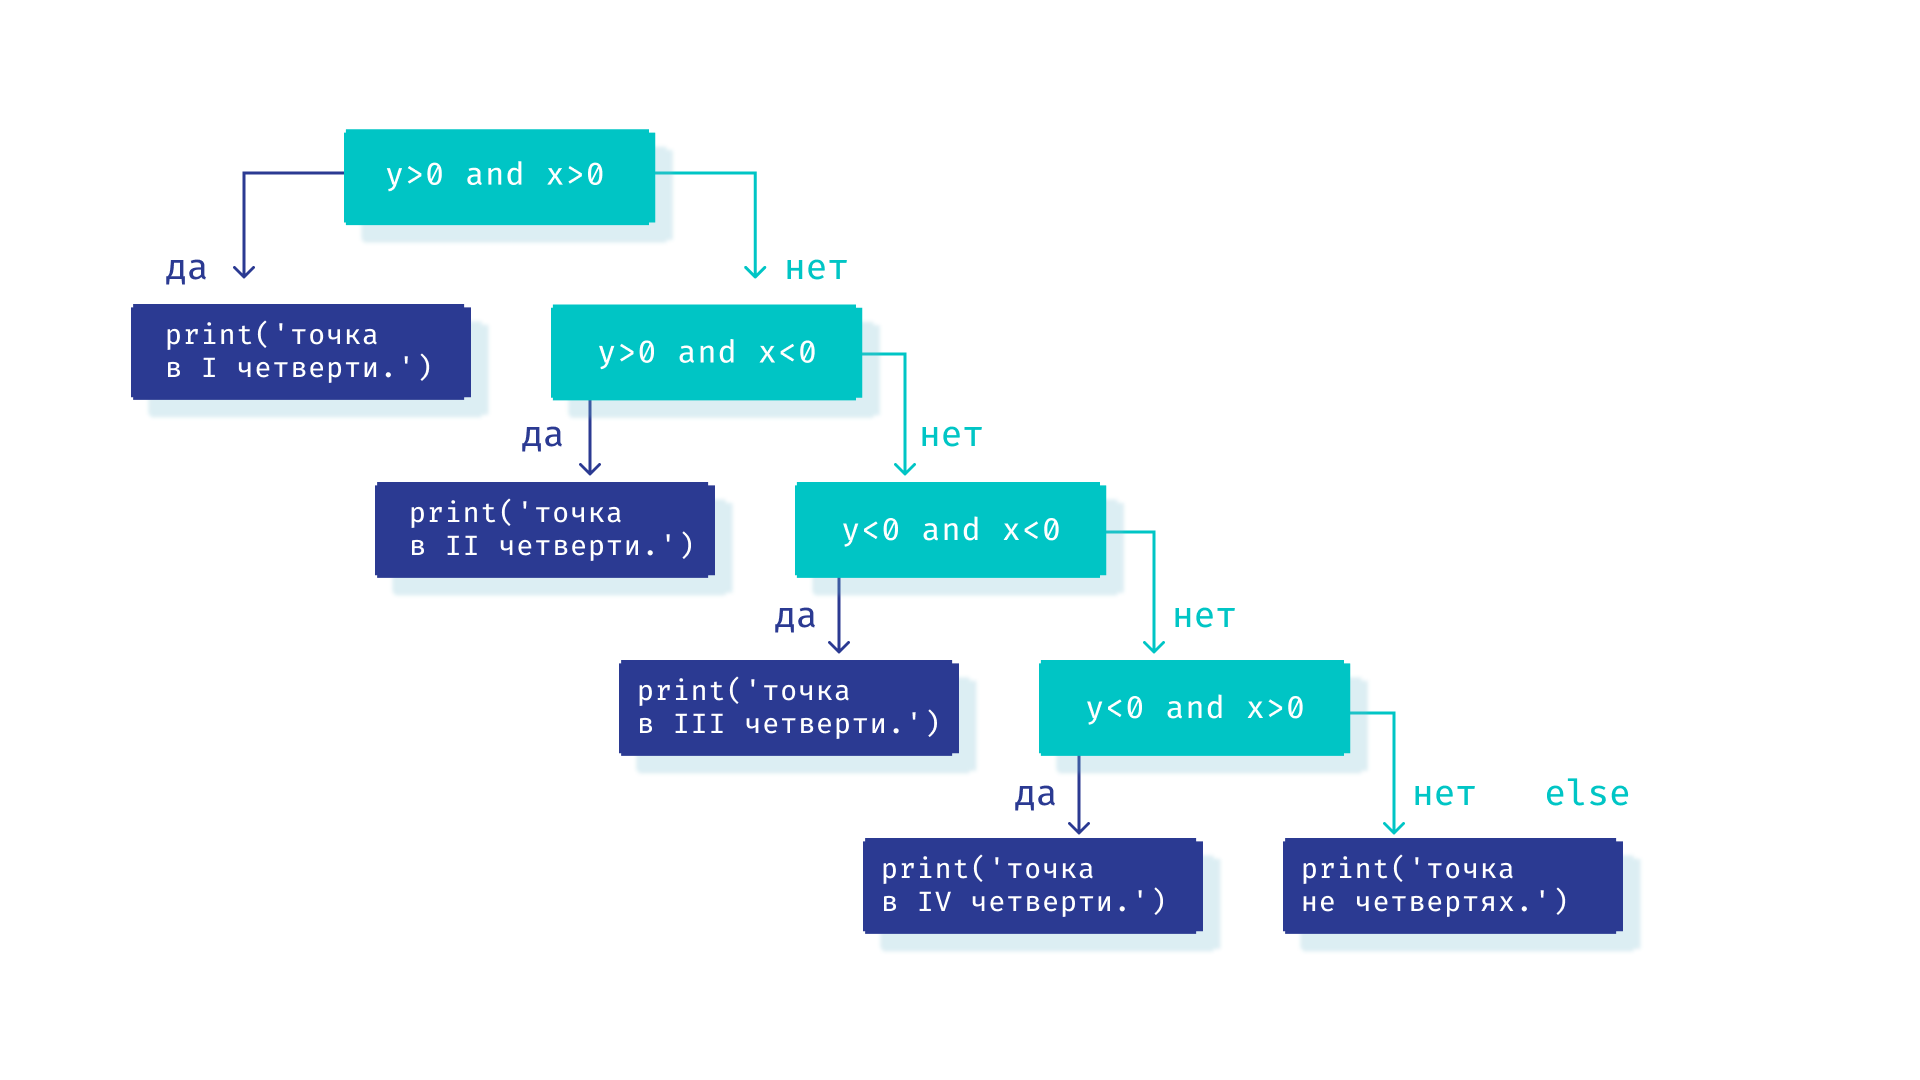